Explainable Credit Risk Assessment
1. Load the Data
We will bring in the loan applicant data.
This data has details like income, age, and loan amount.
It also tells us who repaid and who defaulted.

In [131]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as  plt 
import seaborn as sns

In [132]:
df=pd.read_csv("credit_risk_dataset.csv")

In [133]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


2. Exploratory Data Analysis (EDA)
Here we simply look at the data before touching it.
We want to understand it first, then work on it.

1.Check how many rows and columns we have.
2.Check the data type of each column.

In [134]:
df.shape

(32581, 12)

In [135]:
df.shape 
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB
None


3. Numerical Feature Range Analysis
Check the minimum and maximum values of all numerical columns.

4. Categorical Feature Analysis
Check all unique values present in each categorical column.

In [136]:
# Check the minimum and maximum values of all numerical columns
for col in df.select_dtypes(include='number').columns:
    print(col, "min:", df[col].min(), "max:", df[col].max())

person_age min: 20 max: 144
person_income min: 4000 max: 6000000
person_emp_length min: 0.0 max: 123.0
loan_amnt min: 500 max: 35000
loan_int_rate min: 5.42 max: 23.22
loan_status min: 0 max: 1
loan_percent_income min: 0.0 max: 0.83
cb_person_cred_hist_length min: 2 max: 30


In [137]:
# Check all unique values present in each categorical column
for col in df.select_dtypes(include=['object', 'category']).columns:
    print(col, ":", df[col].unique())

person_home_ownership : ['RENT' 'OWN' 'MORTGAGE' 'OTHER']
loan_intent : ['PERSONAL' 'EDUCATION' 'MEDICAL' 'VENTURE' 'HOMEIMPROVEMENT'
 'DEBTCONSOLIDATION']
loan_grade : ['D' 'B' 'C' 'A' 'E' 'F' 'G']
cb_person_default_on_file : ['Y' 'N']


In [138]:
print("Memory before:", df.memory_usage(deep=True).sum() / 1024**2, "MB")

Memory before: 8.626395225524902 MB


In [139]:
# Optimize selected columns based on their expected value ranges and categories

df['person_age'] = df['person_age'].astype('uint8')

df['person_home_ownership'] = df['person_home_ownership'].astype('category')
df['loan_intent'] = df['loan_intent'].astype('category')
df['loan_grade'] = df['loan_grade'].astype('category')
df['cb_person_default_on_file'] = df['cb_person_default_on_file'].astype('category')

df['loan_status'] = df['loan_status'].astype('uint8')

In [140]:
print("Memory after:", df.memory_usage(deep=True).sum() / 1024**2, "MB")

Memory after: 1.6796884536743164 MB


In [141]:
print("Shape:", df.shape)

Shape: (32581, 12)


In [142]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   person_age                  32581 non-null  uint8   
 1   person_income               32581 non-null  int64   
 2   person_home_ownership       32581 non-null  category
 3   person_emp_length           31686 non-null  float64 
 4   loan_intent                 32581 non-null  category
 5   loan_grade                  32581 non-null  category
 6   loan_amnt                   32581 non-null  int64   
 7   loan_int_rate               29465 non-null  float64 
 8   loan_status                 32581 non-null  uint8   
 9   loan_percent_income         32581 non-null  float64 
 10  cb_person_default_on_file   32581 non-null  category
 11  cb_person_cred_hist_length  32581 non-null  int64   
dtypes: category(4), float64(3), int64(3), uint8(2)
memory usage: 1.7 MB


Missing values
Find out which columns have empty or missing values.
This tells us where we may need to fix things later.

In [143]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


Target balance
Check how many people defaulted vs how many repaid.
This tells us if our data is balanced or imbalanced.

In [144]:
df['loan_status'].unique()

df['loan_status'].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

<Axes: xlabel='loan_status', ylabel='count'>

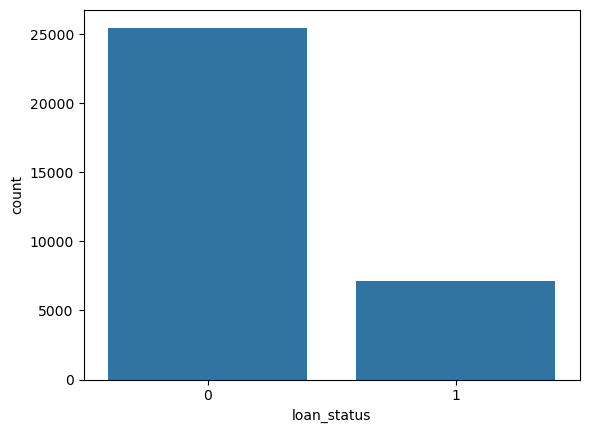

In [145]:
sns.countplot(x='loan_status', data=df)

Outlier check
Look for values that seem impossible, like age 144.
These are signs of bad data entries.

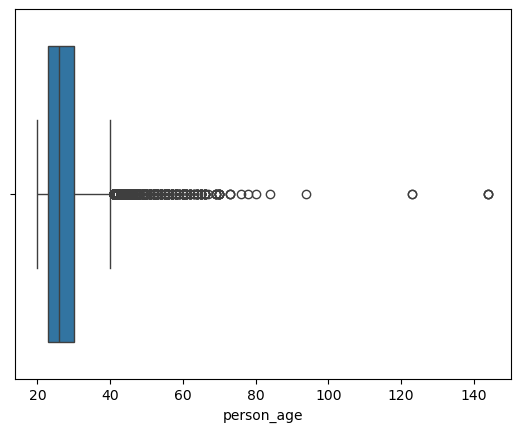

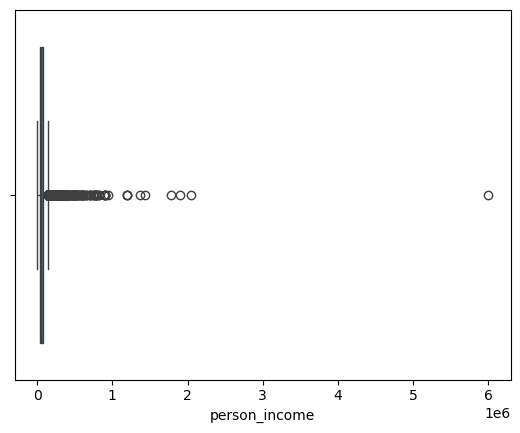

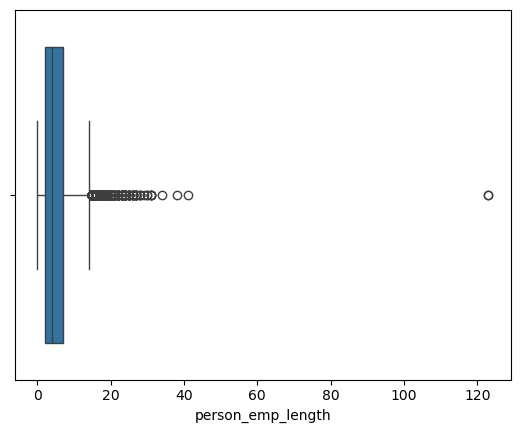

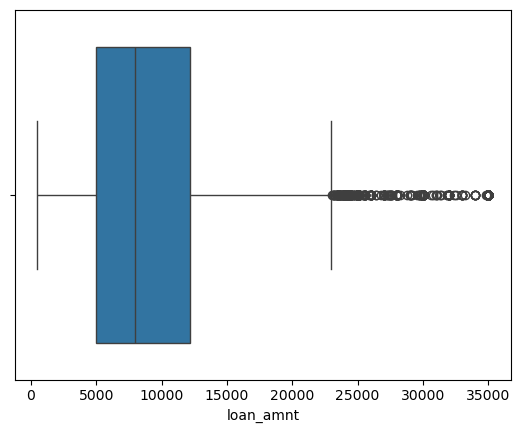

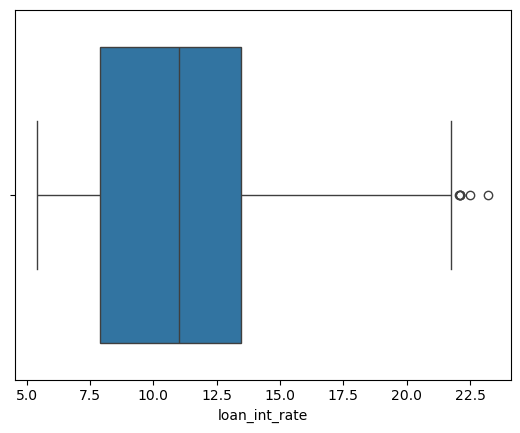

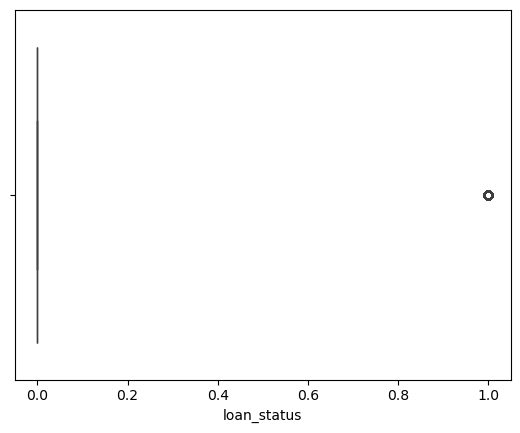

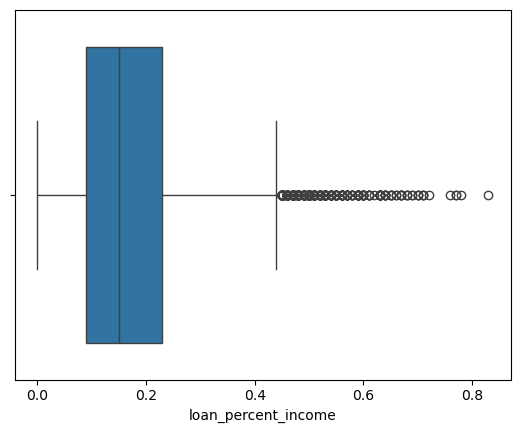

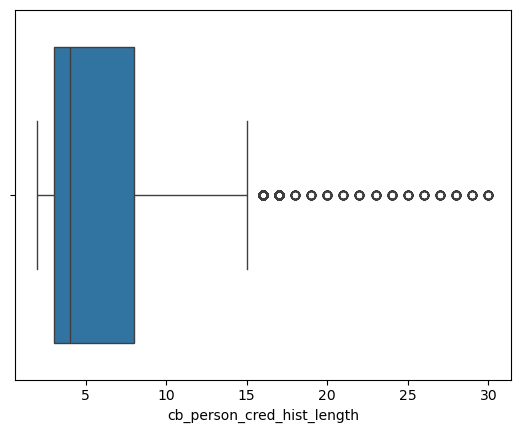

In [146]:
numerical_cols = df.select_dtypes(include=np.number).columns

for i in numerical_cols:
  sns.boxplot(x=df[i])
  plt.show()

In [147]:
(df['person_age'] > 100).sum()

np.int64(5)

In [148]:
(df['person_emp_length'] > 60).sum()

np.int64(2)

In [149]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


Correlation check
See how strongly features are related to each other.
This helps us spot repeated or linked information.

<Axes: >

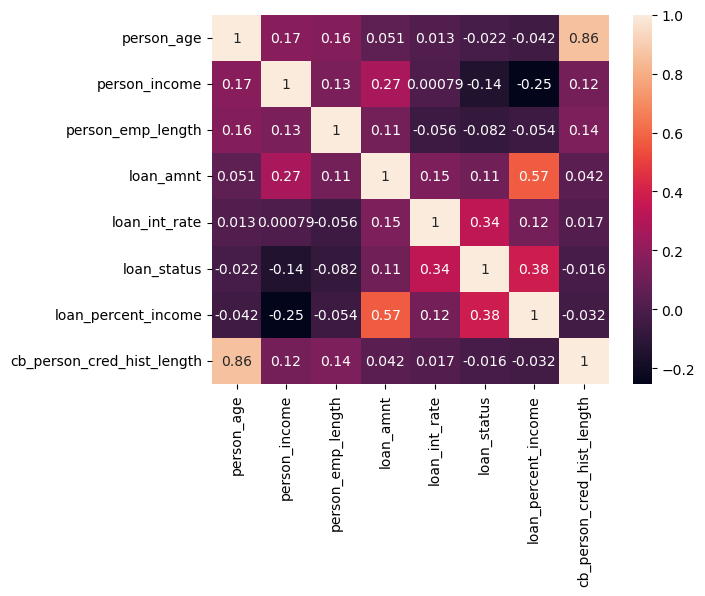

In [150]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

3. Data Validation & Outlier Handling
Here we clean the data properly.
We remove duplicate rows.
We remove rows with an impossible age or work experience.
We remove rows with zero or negative income and loan amount.
We check if the interest rate looks realistic.
We also flag rows where numbers don't add up correctly.

In [151]:
df.duplicated().sum()

np.int64(165)

In [152]:
df_copy=df.copy()
print(f"Original Rows: {df_copy.shape[0]}")

Original Rows: 32581


In [153]:
#Remove Duplicate rows
df_copy.drop_duplicates(inplace=True)
print(f"Rows after removing duplicates : {df_copy.shape[0]}")

Rows after removing duplicates : 32416


In [154]:
print("Age below 18:", (df['person_age'] < 18).sum())
print("Age above 100:", (df['person_age'] > 100).sum())

Age below 18: 0
Age above 100: 5


In [155]:
print("Employment length > age:", 
      (df['person_emp_length'] > df['person_age']).sum())

print("Employment length > 60:", 
      (df['person_emp_length'] > 60).sum())

Employment length > age: 2
Employment length > 60: 2


In [156]:
print("Loan amount <= 0:", (df['loan_amnt'] <= 0).sum())

Loan amount <= 0: 0


In [157]:
df[df['person_age'] > 100][['person_age']]

,person_age
81,144
183,144
575,123
747,123
32297,144


In [158]:
df[df['person_emp_length'] > df['person_age']][
    ['person_age', 'person_emp_length']
]

,person_age,person_emp_length
0,22,123.0
210,21,123.0


In [159]:
df[df['person_emp_length'] > 60][
    ['person_age', 'person_emp_length']
]

,person_age,person_emp_length
0,22,123.0
210,21,123.0


In [160]:
df_copy = df_copy[
    (df_copy['person_age'] >= 18) &
    (df_copy['person_age'] <= 100) &
    (
        df_copy['person_emp_length'].isna() |
        (df_copy['person_emp_length'] <= df_copy['person_age'])
    ) &
    (
        df_copy['person_emp_length'].isna() |
        (df_copy['person_emp_length'] <= 60)
    )
]

In [161]:
print(f"Rows after removing outliers : {df_copy.shape[0]}")

Rows after removing outliers : 32409


4. Features, Target & Train-Test Split
We separate the data into input features and the target.
The target is whether the applicant defaulted or not.
We split the data into a training part and a testing part.
The model learns from the training part only.

In [162]:
X = df_copy.drop('loan_status', axis=1)
y = df_copy['loan_status'] #1, 0

In [163]:
X.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,0.55,Y,4
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,0.25,N,2


In [164]:
y.head()

1    0
2    1
3    1
4    1
5    1
Name: loan_status, dtype: uint8

In [165]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [166]:
numeric_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
                     'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
     

5. Handle Class Imbalance
Very few people actually default in this data.
If we ignore this, the model may just favor the majority class.
We give more importance to the minority class during training.
This helps the model actually learn to spot defaulters.

In [167]:
#0 -> no loan (most)
#1 -> yes loan

neg, pos = np.bincount(y_train)
scale_weigths = neg/pos

In [168]:
scale_weigths

np.float64(3.572663139329806)


6. Data Preprocessing — Pipelines & Column Transformer
Raw data is not ready for a model directly.
We need to prepare numeric and text columns differently.
We will build a Pipeline for each model.
We will use ColumnTransformer to apply different steps to different columns.

Preprocessing for Logistic Regression
Fill missing numeric values.
Scale numeric values, since this model is sensitive to scale.
Convert category columns into numbers using one-hot encoding.

In [169]:

#Logistic Regression : impute + SCALE Numeric, impute + One-Hot-Encoding
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor_lr = ColumnTransformer(
    transformers=[
        #Pipeline - for numerical cols
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_cols),

        #Pipeline - for Categorical cols.
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy="constant", fill_value="Missing")),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ])


Preprocessing for XGBoost
Fill missing numeric values.
No scaling needed here, since tree models don't need it.
Convert category columns into numbers using one-hot encoding.

In [170]:
#XGBoost: Impute numeric only (No Scaling), impute + One - Hot Encoding

preprocessor_xg = ColumnTransformer(
    transformers=[
        #Pipeline - for numerical cols
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median'))
        ]), numeric_cols),

        #Pipeline - for Categorical cols.
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy="constant", fill_value="Missing")),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ])


In [171]:
#stratify=y #train aur test dono mein 0 aur 1 ka approximately same percentage rahega as original dataset.


7. Evaluation Helper Function
We build one common function to check any model's performance.
It will show accuracy, precision, recall, F1 score, and more.
It will also show a confusion matrix and a precision-recall curve.

In [172]:
#We have to evaluate Logistic Model and XGBoost model on the basis of their metrics

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, precision_recall_curve
def evaluate_model(model_name, model, X_test, y_test, threshold=None):
  y_pred_prob = model.predict_proba(X_test)[:,1]

  if threshold:
    y_pred = (y_pred_prob > threshold).astype(int)
  else:
    y_pred = model.predict(X_test)

  #Metrics
  accuracy     = accuracy_score(y_test, y_pred)    #Overall model's preformance
  precision    = precision_score(y_test, y_pred)   #When the model says 1, how oftenly is it actually 1.
  recall       = recall_score(y_test, y_pred)      #of the actual 1 how many did the model catches
  f1           = f1_score(y_test, y_pred)          #Harmonic mean of precision and recall

  conf_matrix   = confusion_matrix(y_test, y_pred)
  class_report  = classification_report(y_test, y_pred)


  print(f"{model_name} Metrics:")
  if threshold is not None: # Only print threshold if provided
    print(f"Used Threshold : {threshold:.2f}")
  print(f"Accuracy : {accuracy:.2f}")
  print(f"Precision : {precision:.2f}")
  print(f"Recall : {recall:.2f}")
  print(f"F1 : {f1:.2f}")
  print()
  print(f"{model_name} Classification Report:")
  print(class_report)


  #Plotting confusion matrix
  sns.heatmap(conf_matrix, annot=True, fmt="d")
  plt.title(f"{model_name} Confusion Matrix")
  plt.ylabel("Actual Values")
  plt.xlabel("Predicted Values")
  plt.show()


  #Plotting ROC-AUC curve
  precisions, recalls, threshold = precision_recall_curve(y_test, y_pred_prob)
  plt.plot(recalls, precisions)
  plt.xlabel("Recall")
  plt.ylabel("Precision")
  plt.title(f"{model_name} Precision-Recall Curve")
  plt.show()

##Cross-Validation (CV) → General technique jisme data ko multiple folds me divide karke model ko multiple times train/test karte hain.
Stratified Cross-Validation → Cross-validation ka special type, jisme har fold me target classes ka proportion approximately same rakha jata hai.

In [173]:
from sklearn.model_selection import StratifiedKFold, cross_validate
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {'roc_auc':'roc_auc', 'accuracy':'accuracy', 'precision':'precision', 'recall':'recall', 'f1':'f1'}
     

In [174]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
lr_cv_pipeline = Pipeline([
    ('preprocessor', preprocessor_lr),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])

In [175]:
import pip
!pip install xgboost

In [176]:
import pip
!pip install xgboost
#XGboost Model
from xgboost import XGBClassifier
xgb_cv_pipeline = Pipeline([
    ('preprocessor', preprocessor_xg),
    ('classifier', XGBClassifier(
        n_estimator=300, max_depth=5, learning_rate=0.1,
        scale_pos_weight=scale_weigths,random_state=42
    ))
])

In [177]:
for cv_name, pipe in [("Logistic Regression", lr_cv_pipeline),
                      ("XGBoost", xgb_cv_pipeline)]:

                      cv_results = cross_validate(pipe, X_train , y_train, cv=cv, scoring=scoring, n_jobs=-1)

                      print(cv_name)
                      print(f"ROC-AUC : {cv_results['test_roc_auc'].mean()}")
                      print(f"Accuracy : {cv_results['test_accuracy'].mean()}")
                      print(f"Precision : {cv_results['test_precision'].mean()}")
                      print(f"Recall : {cv_results['test_recall'].mean()}")
                      print(f"F1 : {cv_results['test_f1'].mean()}")
                      print()

Logistic Regression
ROC-AUC : 0.8702172732054532
Accuracy : 0.8123188199369193
Precision : 0.5504124367547936
Recall : 0.7754850088183421
F1 : 0.6438157956858388

XGBoost
ROC-AUC : 0.9397485264660659
Accuracy : 0.9041150921496606
Precision : 0.7762866945647315
Recall : 0.7892416225749559
F1 : 0.7826596510830623



9. Baseline Model — Logistic Regression
We start with a simple model first.
This becomes our benchmark to beat.
We train it and check its score on the test data.

In [178]:
from sklearn.pipeline import Pipeline
baseline_model = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(class_weight= "balanced"))
])
baseline_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Baseline Logistic Model Metrics:
Accuracy : 0.81
Precision : 0.54
Recall : 0.78
F1 : 0.64

Baseline Logistic Model Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.81      0.87      5064
           1       0.54      0.78      0.64      1418

    accuracy                           0.81      6482
   macro avg       0.73      0.80      0.75      6482
weighted avg       0.84      0.81      0.82      6482



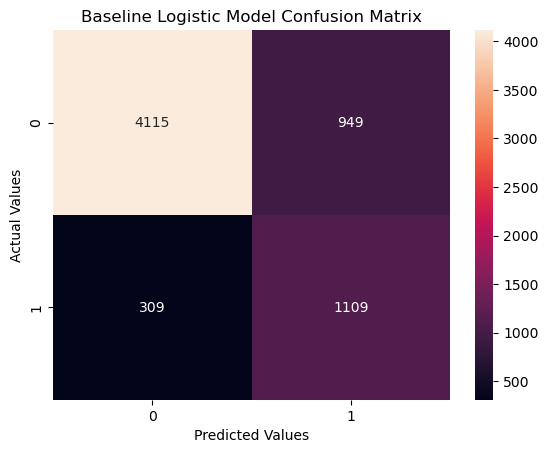

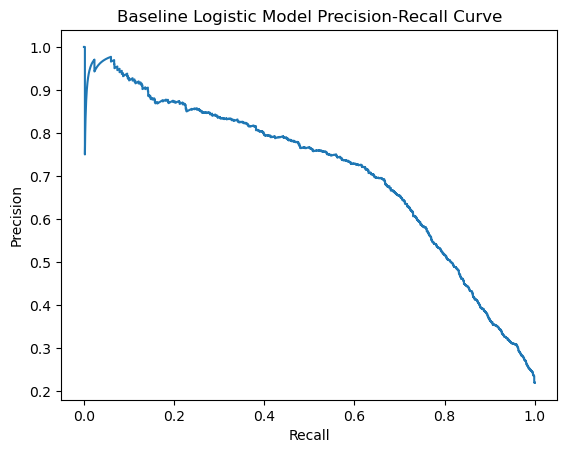

In [179]:
evaluate_model("Baseline Logistic Model", baseline_model ,X_test, y_test)
     

10. XGBoost Hyperparameter Tuning
Now we move to a stronger model, XGBoost.
A model has many settings called hyperparameters.
We search for the best combination of these settings.
We use cross-validation while searching, so the result is reliable.

In [180]:
xg_model = Pipeline([
    ('preprocessor', preprocessor_xg),
    ('classifier', XGBClassifier(learning_rate=0.1,
        scale_pos_weight=scale_weigths,random_state=42))
])
xg_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


xg_baseline_model Metrics:
Accuracy : 0.92
Precision : 0.81
Recall : 0.81
F1 : 0.81

xg_baseline_model Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      5064
           1       0.81      0.81      0.81      1418

    accuracy                           0.92      6482
   macro avg       0.88      0.88      0.88      6482
weighted avg       0.92      0.92      0.92      6482



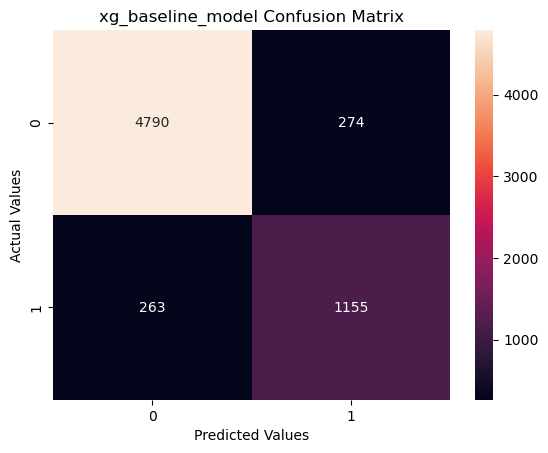

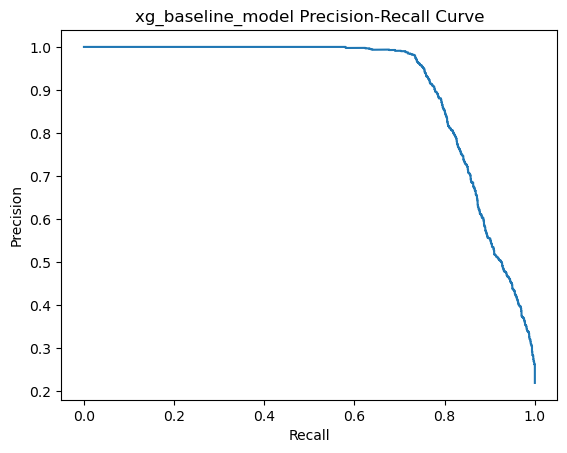

In [181]:
evaluate_model("xg_baseline_model", xg_model ,X_test, y_test)

In [182]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

param_grid = {
    "classifier__n_estimators": randint(150, 600),
    "classifier__max_depth" : randint(3,9),
    "classifier__learning_rate" : uniform(0.01, 0.5),
    "classifier__subsample": uniform(0.6,0.4), #Rows sampling
    "classifier__colsample_bytree" :uniform(0.6,0.4), #column sampling
    "classifier__min_child_weight": randint(1, 10),
    "classifier__gamma": uniform(0 , 5)
}
# lower gamma -> more splits -> complex tree -> higher overfitting risk
# higher gamma -> less splits ->  simpler tree -> low overfitting

In [183]:
random_search = RandomizedSearchCV(
    xg_model,
    param_grid,
    n_iter=150,
    cv=cv,
    scoring="average_precision",
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 150 candidates, totalling 750 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'classifier__colsample_bytree': <scipy.stats....0015A74BE5440>, 'classifier__gamma': <scipy.stats....0015A74BE5A70>, 'classifier__learning_rate': <scipy.stats....0015A74D50B90>, 'classifier__max_depth': <scipy.stats....0015A74735B80>, ...}"
,n_iter,150
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [184]:
print(f"Score after performing Tunning {random_search.best_score_:.2f}")

Score after performing Tunning 0.90


In [185]:
print("\nBest CV Average Precision:")
print(random_search.best_score_)


Best CV Average Precision:
0.9028260845893422


In [186]:
random_search.best_params_

{'classifier__colsample_bytree': np.float64(0.8026617301351125),
 'classifier__gamma': np.float64(1.536817187962225),
 'classifier__learning_rate': np.float64(0.10918998083698299),
 'classifier__max_depth': 8,
 'classifier__min_child_weight': 3,
 'classifier__n_estimators': 468,
 'classifier__subsample': np.float64(0.9574203207506748)}

In [187]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform

param_grid_lr = {
    "classifier__C": uniform(0.01, 10),
    "classifier__solver": ["liblinear", "lbfgs"]
}

random_search_lr = RandomizedSearchCV(
    lr_cv_pipeline,
    param_grid_lr,
    n_iter=50,
    cv=cv,
    scoring="average_precision",
    n_jobs=1,
    verbose=1,
    random_state=42
)

random_search_lr.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'classifier__C': <scipy.stats....0015A74C82490>, 'classifier__solver': ['liblinear', 'lbfgs']}"
,n_iter,50
,scoring,'average_precision'
,n_jobs,1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [188]:
print("Best Parameters:", random_search_lr.best_params_)
print("Best Average Precision:", random_search_lr.best_score_)

Best Parameters: {'classifier__C': np.float64(9.74755518841459), 'classifier__solver': 'liblinear'}
Best Average Precision: 0.7196153454230515


Hyptertuned_lr Metrics:
Accuracy : 0.81
Precision : 0.54
Recall : 0.78
F1 : 0.64

Hyptertuned_lr Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.81      0.87      5064
           1       0.54      0.78      0.64      1418

    accuracy                           0.81      6482
   macro avg       0.73      0.80      0.75      6482
weighted avg       0.84      0.81      0.82      6482



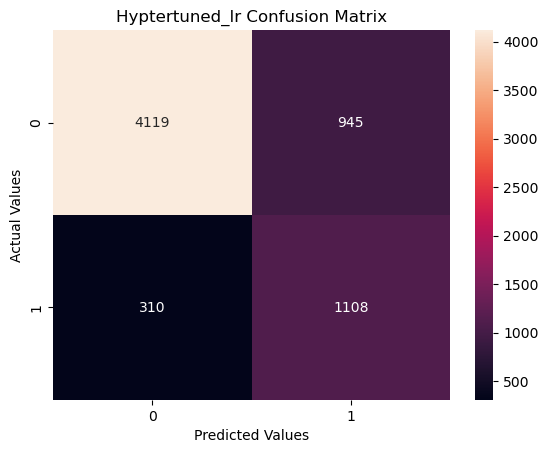

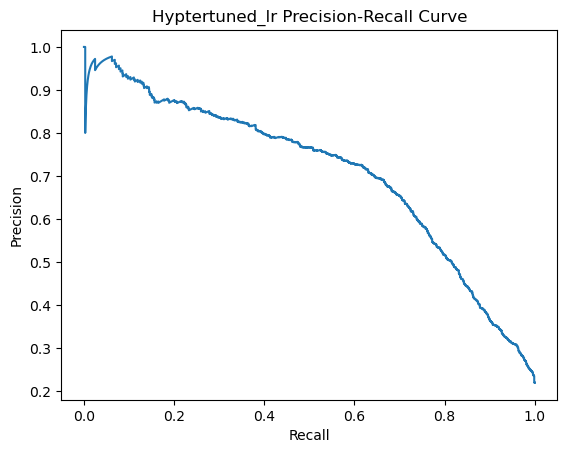

In [189]:
#Passing the XGBoost model after performing Hyperparameter Tuning
evaluate_model("Hyptertuned_lr", random_search_lr, X_test, y_test)

 Hypertuned XGBoost Metrics:
Accuracy : 0.93
Precision : 0.86
Recall : 0.81
F1 : 0.83

 Hypertuned XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      5064
           1       0.86      0.81      0.83      1418

    accuracy                           0.93      6482
   macro avg       0.90      0.89      0.89      6482
weighted avg       0.93      0.93      0.93      6482



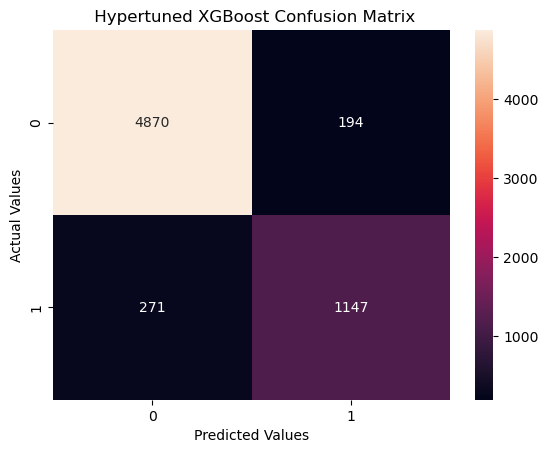

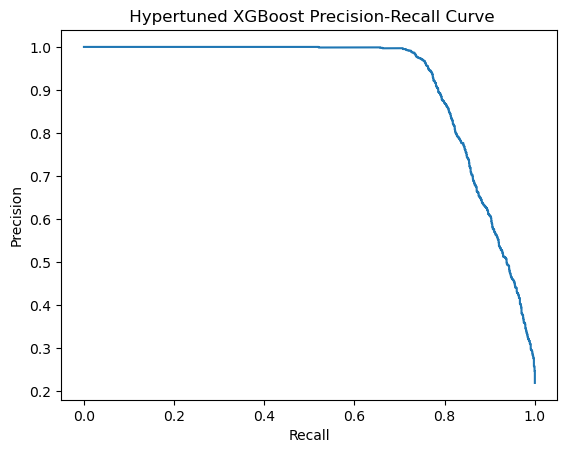

In [190]:
#Passing the XGBoost model after performing Hyperparameter Tuning
evaluate_model(" Hypertuned XGBoost", random_search, X_test, y_test)

12. Optimizing the Classification Threshold
The model gives a probability, not a direct yes or no.
We decide a cut-off point to turn it into a decision.
We check different cut-off points and pick the best one.

In [191]:
from sklearn.metrics import confusion_matrix, accuracy_score


# ============================================================
# HYPERPARAMETER-TUNED XGBOOST
# ============================================================

model = random_search

# Probability of class 1
prob = model.predict_proba(X_test)[:, 1]


# ============================================================
# CHECK THRESHOLDS
# ============================================================

results = []

for threshold in np.arange(0.05, 0.96, 0.01):

    y_pred = (prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred,
        labels=[0, 1]
    ).ravel()

    accuracy = accuracy_score(y_test, y_pred)

    results.append({
        "Threshold": round(threshold, 2),
        "Accuracy": accuracy,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })


results_df = pd.DataFrame(results)


# ============================================================
# ACCURACY >= 90%
# ============================================================

valid = results_df[
    results_df["Accuracy"] >= 0.90
].copy()


# ============================================================
# MINIMUM FN
# ============================================================

best_result = valid.sort_values(
    ["FN", "Threshold"]
).iloc[0]


print("==========================================")
print("BEST THRESHOLD - TUNED XGBOOST")
print("==========================================")

print(best_result)

BEST THRESHOLD - TUNED XGBOOST
Threshold       0.380000
Accuracy        0.901574
TN           4635.000000
FP            429.000000
FN            209.000000
TP           1209.000000
Name: 33, dtype: float64


13. Probability Calibration
Sometimes a model's probability doesn't mean what it says.
For example, 30% risk should truly mean a 30% chance.
We check this with a calibration plot.
We fix it if the probabilities are off.

In [192]:
"""
Methods by which we can fix the poorly calibrated model.
1. Platt Scaling/ Sigmoid -> Adjust the probabilites using a sigmoid curve.
2. Isotonic Regression -> Learn a flexible mapping from old prob. - better prob. (non-linear calibartion)
3. Temperature Scaling -> Adjust the confidence of neural-network predictions using one temperature
"""

'\nMethods by which we can fix the poorly calibrated model.\n1. Platt Scaling/ Sigmoid -> Adjust the probabilites using a sigmoid curve.\n2. Isotonic Regression -> Learn a flexible mapping from old prob. - better prob. (non-linear calibartion)\n3. Temperature Scaling -> Adjust the confidence of neural-network predictions using one temperature\n'

In [193]:
# 1. Calibrated XGBoost model
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

best_model = random_search.best_estimator_

isotonic_model = CalibratedClassifierCV(
    best_model,
    method="isotonic",
    cv=5
)

isotonic_model.fit(X_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,method,'isotonic'
,cv,5
,n_jobs,None
,ensemble,'auto'
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [194]:
# 2. Get probabilities
uncalibrated = xg_model.predict_proba(X_test)[:, 1]
calibrated = isotonic_model.predict_proba(X_test)[:, 1]

In [195]:
#3. create calibration curves
actual_uncal, predicted_uncal = calibration_curve(y_test, uncalibrated, n_bins=10)

In [196]:
actual_cal, predicted_cal  = calibration_curve(y_test, calibrated, n_bins=10)

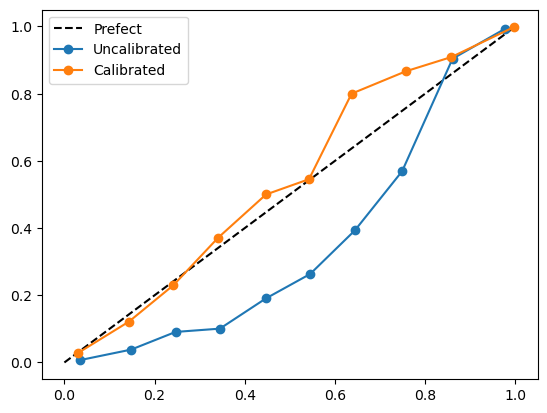

In [197]:
#4. plot
plt.plot([0,1], [0,1], 'k--', label="Prefect")
plt.plot(
    predicted_uncal,
    actual_uncal,
    "o-",
    label = "Uncalibrated"
)

plt.plot(
    predicted_cal,
    actual_cal,
    "o-",
    label = "Calibrated"
)
plt.legend()

In [198]:
# 1. Sigmoid Calibrated XGBoost model
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

best_model = random_search.best_estimator_

sigmoid_model = CalibratedClassifierCV(
    best_model,
    method="sigmoid",
    cv=5
)

sigmoid_model.fit(X_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,method,'sigmoid'
,cv,5
,n_jobs,None
,ensemble,'auto'
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [199]:
# 2. Get probabilities
uncalibrated = xg_model.predict_proba(X_test)[:, 1]
calibrated = sigmoid_model.predict_proba(X_test)[:, 1]

In [200]:
# 3. Create calibration curves
actual_uncal, predicted_uncal = calibration_curve(
    y_test, uncalibrated, n_bins=10
)

actual_cal, predicted_cal = calibration_curve(
    y_test, calibrated, n_bins=10
)

In [201]:
actual_cal, predicted_cal  = calibration_curve(y_test, calibrated, n_bins=10)

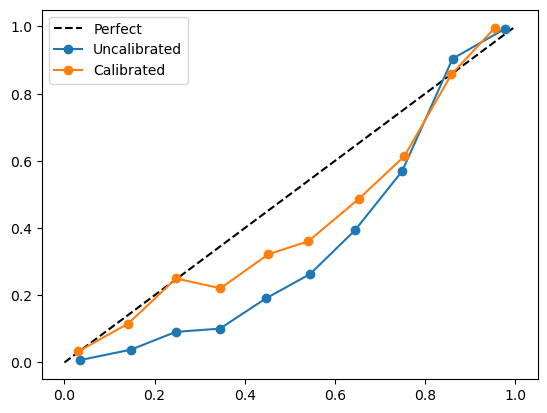

In [202]:
#4. plot
plt.plot([0,1], [0,1], 'k--', label="Perfect")
plt.plot(
    predicted_uncal,
    actual_uncal,
    "o-",
    label = "Uncalibrated"
)

plt.plot(
    predicted_cal,
    actual_cal,
    "o-",
    label = "Calibrated"
)
plt.legend()

In [203]:
from sklearn.metrics import brier_score_loss, log_loss

# Probabilities
prob_isotonic = isotonic_model.predict_proba(X_test)[:, 1]
prob_sigmoid = sigmoid_model.predict_proba(X_test)[:, 1]

# Brier Score
brier_isotonic = brier_score_loss(y_test, prob_isotonic)
brier_sigmoid = brier_score_loss(y_test, prob_sigmoid)

# Log Loss
logloss_isotonic = log_loss(y_test, prob_isotonic)
logloss_sigmoid = log_loss(y_test, prob_sigmoid)

print("Isotonic:")
print("Brier Score :", brier_isotonic)
print("Log Loss    :", logloss_isotonic)

print("\nSigmoid:")
print("Brier Score :", brier_sigmoid)
print("Log Loss    :", logloss_sigmoid)

Isotonic:
Brier Score : 0.049221220075567985
Log Loss    : 0.17610633332714173

Sigmoid:
Brier Score : 0.05059961478572566
Log Loss    : 0.18665007899101357


In [204]:
#Isotonic calibration ne Sigmoid se better calibrated probabilities produce ki hain.

14. SHAP Interpretation — Global & Local
SHAP helps us understand why the model makes a decision.
It is a way of explaining a "black box" model.

In [205]:
#1. Install SHAP if not exists
!pip install shap
import shap

In [206]:
#2. Get the Trained XGBoost classifier model out of the pipeline.
xgb_classifier = xg_model.named_steps['classifier']

In [207]:
#3. Transform X_test using the same preprocessing used for training.
X_test_transformed = xg_model.named_steps['preprocessor'].transform(X_test)

In [208]:
#4. Get feature names after one-hot enocding , so plots are readable
feature_names = xg_model.named_steps['preprocessor'].get_feature_names_out()

In [209]:
#5. Convert to a dataframe for cleaner SHAP plots
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

In [210]:
#6. Create SHAP explainer built for tree-based model
explainer = shap.TreeExplainer(xgb_classifier)     

In [211]:
#7. Calculate SHAP values for every row in the test set
shap_values = explainer.shap_values(X_test_df)
shap_values
     

array([[ 0.13190813,  0.10477926, -0.09859532, ..., -0.00835016,
         0.01122268,  0.        ],
       [ 0.00788426, -0.4754646 ,  0.04425234, ..., -0.00849718,
        -0.01457549,  0.        ],
       [-0.03709772, -0.04976362, -0.09768718, ..., -0.00808257,
        -0.00453841,  0.        ],
       ...,
       [-0.16001312,  0.53496975, -0.00316301, ..., -0.00659344,
        -0.00436232,  0.        ],
       [-0.01318737, -0.82224506, -0.13974573, ..., -0.00965086,
        -0.00436301,  0.        ],
       [-0.05434711, -0.55771494, -0.02005298, ..., -0.00983864,
        -0.00976933,  0.        ]], shape=(6482, 26), dtype=float32)

Global explanation
This shows which features matter most overall.
It also shows if a feature increases or decreases risk.

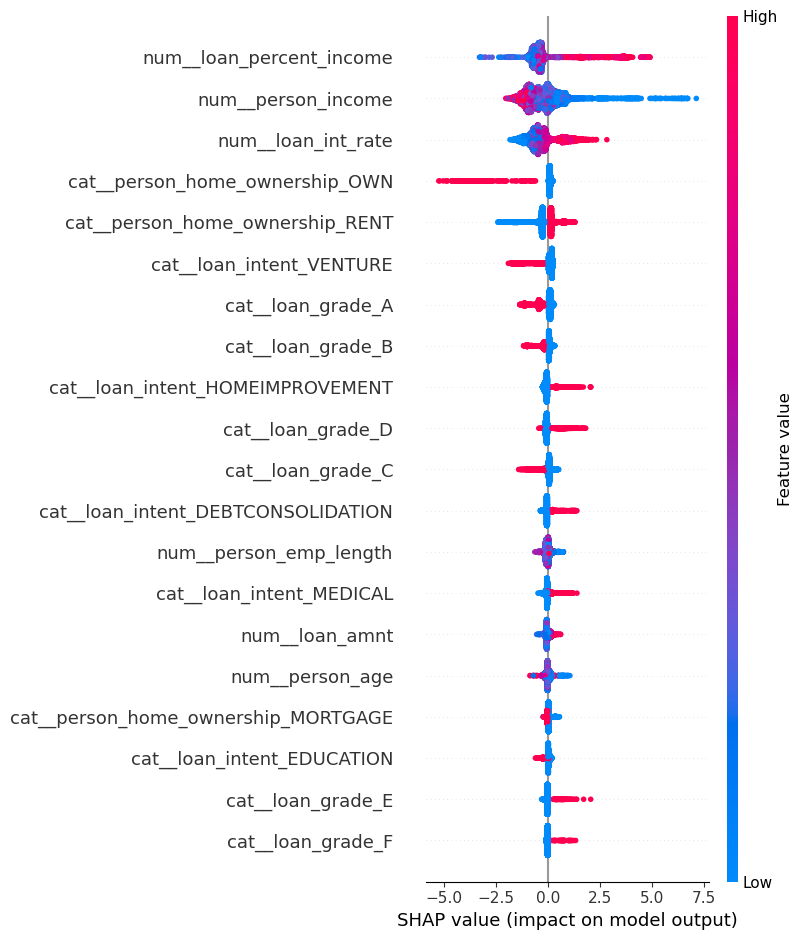

In [212]:
shap.summary_plot(shap_values, X_test_df)

Local explanation
This shows why one specific applicant got their score.
It breaks the score down feature by feature.

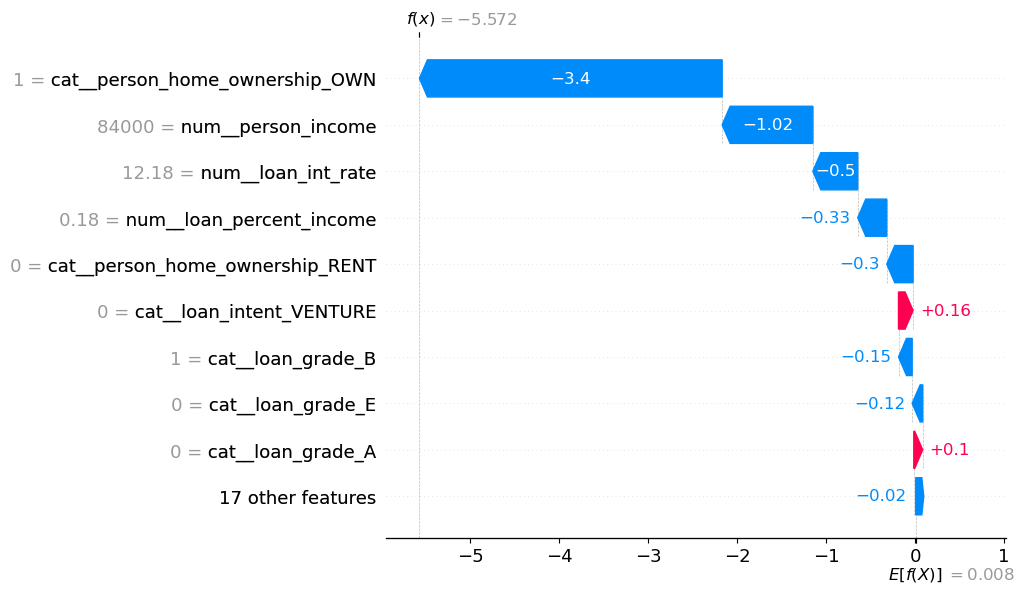

In [213]:
# 1. Pick one row to explain, e.g. the 5th applicant in the test set
row_index = 5

#2. Draw a waterfall plot showing how each feature pushed the prediction up or down.
shap.plots.waterfall(
    shap.Explanation(
        values = shap_values[row_index],
        base_values = explainer.expected_value,
        data = X_test_df.iloc[row_index],
        feature_names = feature_names
    )
)

15. Analyzing False Positives & False Negatives
The model will not be perfect.
False positives are safe people wrongly marked risky.
False negatives are risky people wrongly marked safe.
We study these cases to understand where the model struggles.

In [214]:
#Get predictions from the best performing XGBoost model on the test set
y_pred = xg_model.predict(X_test)

In [215]:
#Create a dataframe to easily compare the actual and predicted values
result_df = X_test.copy()
result_df['actual'] = y_test
result_df['predicted'] = y_pred
     

In [216]:
#Identify False Positive : Model Predicted 1, but the actual was 0
false_positive = result_df[(result_df['actual']== 0) & (result_df['predicted']== 1)]

#Identify False Negative : Model Predicted 0, but the actual was 1
false_negative = result_df[(result_df['actual']== 1) & (result_df['predicted']== 0)]

In [217]:
print(f"False Positive : {len(false_positive)}")
print(f"False Negative : {len(false_negative)}")

False Positive : 274
False Negative : 263


# Model Development, Tuning & Calibration Summary

In this project, multiple Machine Learning models and optimization techniques were evaluated for **Loan Default Prediction**, where:

- **Class 0:** Non-Default
- **Class 1:** Default

Since predicting a defaulter as a non-defaulter is a critical error, **False Negatives (FN)** are an important evaluation metric along with Accuracy, Precision, Recall and F1-Score.

---

## Models Evaluated

A total of **6 model configurations** were evaluated during the modeling phase:

### 1. Baseline Logistic Regression

A basic Logistic Regression pipeline was developed as the initial baseline model.

**Test Performance:**
- Accuracy: **81%**
- Precision: **0.54**
- Recall: **0.78**
- F1-Score: **0.64**
- False Negatives: **310**

**Confusion Matrix:**
- TN = 4119
- FP = 945
- FN = 310
- TP = 1108

This model provides a simple and interpretable baseline for comparison with more advanced models.

---

### 2. Baseline XGBoost

XGBoost was then implemented as a stronger tree-based baseline model.

**Test Performance:**
- Accuracy: **92%**
- Precision: **0.81**
- Recall: **0.81**
- F1-Score: **0.81**

The baseline XGBoost model showed a significant improvement over Logistic Regression in overall predictive performance.

---

### 3. Hyperparameter-Tuned XGBoost

To improve the baseline XGBoost model, **RandomizedSearchCV** with **5-fold Stratified Cross-Validation** was used.

The optimization used **Average Precision** as the scoring metric because the dataset contains class imbalance.

**Best CV Average Precision:**
- **0.9042**

**Best Parameters:**
- `n_estimators = 428`
- `max_depth = 8`
- `learning_rate ≈ 0.0456`
- `min_child_weight = 4`
- `gamma ≈ 1.928`
- `subsample ≈ 0.872`
- `colsample_bytree ≈ 0.982`

**Test Performance at threshold 0.50:**
- Accuracy: **93%**
- Precision: **0.84**
- Recall: **0.81**
- F1-Score: **0.82**
- FN: **275**

**Confusion Matrix:**
- TN = 4853
- FP = 211
- FN = 275
- TP = 1143

Threshold analysis was also performed to reduce False Negatives.

**Selected threshold from FN-focused threshold analysis:**
- Threshold = **0.38**
- Accuracy ≈ **90.03%**
- FN = **211**
- TP = **1207**

This demonstrates that changing the classification threshold can significantly reduce False Negatives at the cost of some overall accuracy.

---

### 4. Hyperparameter-Tuned Logistic Regression

Logistic Regression was also optimized using **RandomizedSearchCV** with 5-fold Stratified Cross-Validation.

**Best CV Average Precision:**
- **≈ 0.7196**

**Best Parameters:**
- `C ≈ 9.748`
- `solver = liblinear`

**Test Performance:**
- Accuracy: **81%**
- Precision: **0.54**
- Recall: **0.78**
- F1-Score: **0.64**
- FN: **310**

The tuned Logistic Regression did not provide a meaningful improvement over the baseline Logistic Regression on the test set.

---


# Probability Calibration & Threshold Optimization

After hyperparameter tuning, the tuned XGBoost model was further evaluated using **probability calibration**.

The objective of calibration was to improve the reliability of the predicted probabilities so that the output probabilities could be used more effectively for threshold-based decision making.

Two calibration techniques were tested:

- **Isotonic Calibration**
- **Sigmoid Calibration**

---

## Isotonic Calibration

The tuned XGBoost model was calibrated using the **Isotonic** method.

Isotonic calibration is a non-parametric calibration technique that learns a monotonic relationship between the original model probabilities and the observed probability of the positive class.

The calibrated model was evaluated using:

- **Brier Score = 0.04963**
- **Log Loss = 0.17744**

Lower values indicate better probability calibration.

---

## Sigmoid Calibration

The same tuned XGBoost model was also calibrated using the **Sigmoid** method.

Sigmoid calibration fits a logistic transformation to the model's raw probability outputs.

The calibrated model achieved:

- **Brier Score = 0.05130**
- **Log Loss = 0.18257**

---

## Comparison of Calibration Methods

Both calibration methods were evaluated using **Brier Score, Log Loss and calibration curves**.

| Calibration Method | Brier Score | Log Loss |
|---|---:|---:|
| **Isotonic** | **0.04963** | **0.17744** |
| Sigmoid | 0.05130 | 0.18257 |

The calibration results show that **Isotonic calibration produced lower Brier Score and Log Loss** than Sigmoid calibration.

The calibration curve was also plotted to visually compare the predicted probabilities with the observed probabilities. Based on the calibration evaluation and graph, **Isotonic calibration showed better probability calibration for this dataset**.

Therefore, Isotonic calibration was considered a stronger candidate for the subsequent threshold optimization stage.

---

# Threshold Optimization After Calibration

After calibration, threshold analysis was performed separately for both the **Isotonic XGBoost** and **Sigmoid XGBoost** models.

Instead of using the default classification threshold of `0.50`, multiple thresholds were evaluated to understand their effect on:

- Accuracy
- Precision
- Recall
- F1-Score
- False Positives (FP)
- False Negatives (FN)
- True Positives (TP)

This is particularly important for the loan default problem because:

> **False Negative = Actual loan defaulter predicted as a non-defaulter.**

Therefore, reducing False Negatives is an important consideration during threshold selection.

---

## Maximum Accuracy Threshold

### Isotonic XGBoost

The maximum accuracy obtained was:

- Threshold = **0.39**
- Accuracy = **94.0296%**
- Precision = **0.9582**
- Recall = **0.7602**
- F1-Score = **0.8478**
- FN = **340**

The same maximum accuracy was also obtained at threshold `0.41`.

However:

- Threshold `0.39` → FN = **340**
- Threshold `0.41` → FN = **346**

Therefore, when maximum accuracy is the objective, threshold **0.39** provides the same accuracy with fewer False Negatives.

### Sigmoid XGBoost

The maximum accuracy obtained was:

- Threshold = **0.65**
- Accuracy = **93.9988%**
- Precision = **0.9651**
- Recall = **0.7525**
- F1-Score = **0.8458**
- FN = **351**

The maximum accuracy of Isotonic XGBoost was slightly higher than that of Sigmoid XGBoost, while also producing fewer False Negatives at their respective maximum-accuracy thresholds.

---

# Balanced Threshold Analysis

Since maximum accuracy alone does not capture the importance of False Negatives, a separate balanced threshold analysis was performed.

The analysis considered both:

- Overall Accuracy
- Reduction in False Negatives

### Isotonic XGBoost

The selected balanced threshold was:

- Threshold = **0.19**
- Accuracy = **89.5865%**
- Precision = **0.7192**
- Recall = **0.8597**
- F1-Score = **0.7832**
- FP = **476**
- FN = **199**
- TP = **1219**

### Sigmoid XGBoost

The selected balanced threshold was:

- Threshold = **0.24**
- Accuracy = **91.1447%**
- Precision = **0.7755**
- Recall = **0.8378**
- F1-Score = **0.8054**
- FP = **344**
- FN = **230**
- TP = **1188**

Although the Sigmoid model achieved higher accuracy at its selected balanced threshold, the Isotonic model produced **31 fewer False Negatives**.

---

# Final Observation from Calibration & Threshold Analysis

Both **Isotonic** and **Sigmoid** calibration were tested on the same tuned XGBoost model.

The results were compared using:

1. **Brier Score**
2. **Log Loss**
3. **Calibration Curve**
4. **Maximum Accuracy**
5. **False Negatives**
6. **Threshold-based performance**

Overall, **Isotonic calibration performed better in probability calibration**, achieving lower Brier Score and Log Loss. The calibration graph also showed better alignment between predicted probabilities and observed probabilities.

After threshold optimization, Isotonic XGBoost also provided operating points with fewer False Negatives compared with Sigmoid XGBoost.

Therefore, based on the combined calibration results and the importance of reducing missed loan defaults, **Isotonic XGBoost emerged as the stronger candidate for the final model selection**.

The final threshold will be selected based on the desired trade-off between **Accuracy and False Negatives**, with particular attention given to minimizing the risk of missing actual loan defaulters.

In [218]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


# ============================================================
# FUNCTION
# ============================================================

def analyze_thresholds(model, model_name, X_test, y_test):

    # Get probability of class 1 = Default
    y_prob = model.predict_proba(X_test)[:, 1]

    results = []

    # Check 0.01 → 0.99
    for threshold in np.arange(0.01, 1.00, 0.01):

        y_pred = (y_prob >= threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_test,
            y_pred,
            labels=[0, 1]
        ).ravel()

        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(
            y_test,
            y_pred,
            zero_division=0
        )
        recall = recall_score(
            y_test,
            y_pred,
            zero_division=0
        )
        f1 = f1_score(
            y_test,
            y_pred,
            zero_division=0
        )

        results.append({
            "Model": model_name,
            "Threshold": round(threshold, 2),
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp
        })

    df = pd.DataFrame(results)

    # ========================================================
    # MAXIMUM ACCURACY
    # ========================================================

    max_accuracy = df["Accuracy"].max()

    max_accuracy_rows = df[
        df["Accuracy"] == max_accuracy
    ].copy()


    # ========================================================
    # MINIMUM FN
    # ========================================================

    min_fn = df["FN"].min()

    min_fn_rows = df[
        df["FN"] == min_fn
    ].copy()


    # ========================================================
    # BEST BALANCED RESULT
    # ========================================================
    #
    # Normalize Accuracy and FN
    #
    # Higher accuracy = better
    # Lower FN = better
    #
    # Score:
    # 60% Accuracy
    # 40% FN reduction
    #
    # ========================================================

    accuracy_norm = (
        (df["Accuracy"] - df["Accuracy"].min()) /
        (df["Accuracy"].max() - df["Accuracy"].min())
    )

    fn_norm = (
        (df["FN"].max() - df["FN"]) /
        (df["FN"].max() - df["FN"].min())
    )

    df["Balanced_Score"] = (
        0.60 * accuracy_norm +
        0.40 * fn_norm
    )

    best_balanced = df.loc[
        df["Balanced_Score"].idxmax()
    ]


    return (
        df,
        max_accuracy_rows,
        min_fn_rows,
        best_balanced
    )


# ============================================================
# 1. ISOTONIC
# ============================================================

(
    isotonic_results,
    isotonic_max_acc,
    isotonic_min_fn,
    isotonic_best
) = analyze_thresholds(
    isotonic_model,
    "Isotonic XGBoost",
    X_test,
    y_test
)


# ============================================================
# 2. SIGMOID
# ============================================================

(
    sigmoid_results,
    sigmoid_max_acc,
    sigmoid_min_fn,
    sigmoid_best
) = analyze_thresholds(
    sigmoid_model,
    "Sigmoid XGBoost",
    X_test,
    y_test
)


# ============================================================
# MAX ACCURACY
# ============================================================

print("\n==============================================")
print("MAXIMUM ACCURACY")
print("==============================================\n")

print(
    pd.concat(
        [
            isotonic_max_acc,
            sigmoid_max_acc
        ]
    )[
        [
            "Model",
            "Threshold",
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "FP",
            "FN",
            "TP"
        ]
    ].to_string(index=False)
)


# ============================================================
# MINIMUM FN
# ============================================================

print("\n==============================================")
print("MINIMUM FN")
print("==============================================\n")

print(
    pd.concat(
        [
            isotonic_min_fn,
            sigmoid_min_fn
        ]
    )[
        [
            "Model",
            "Threshold",
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "FP",
            "FN",
            "TP"
        ]
    ].to_string(index=False)
)


# ============================================================
# BEST BALANCED
# ============================================================

print("\n==============================================")
print("BEST BALANCED THRESHOLD")
print("==============================================\n")

best_balanced_df = pd.DataFrame([
    isotonic_best,
    sigmoid_best
])

print(
    best_balanced_df[
        [
            "Model",
            "Threshold",
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "FP",
            "FN",
            "TP",
            "Balanced_Score"
        ]
    ].to_string(index=False)
)


MAXIMUM ACCURACY

           Model  Threshold  Accuracy  Precision   Recall       F1  FP  FN   TP
Isotonic XGBoost       0.47  0.940296   0.972502 0.748237 0.845755  30 357 1061
 Sigmoid XGBoost       0.69  0.940296   0.973370 0.747532 0.845632  29 358 1060
 Sigmoid XGBoost       0.70  0.940296   0.975993 0.745416 0.845262  26 361 1057
 Sigmoid XGBoost       0.71  0.940296   0.977757 0.744006 0.845014  24 363 1055
 Sigmoid XGBoost       0.72  0.940296   0.978644 0.743300 0.844890  23 364 1054

MINIMUM FN

           Model  Threshold  Accuracy  Precision   Recall       F1   FP  FN   TP
Isotonic XGBoost       0.01  0.421629   0.273909 0.995769 0.429636 3743   6 1412
 Sigmoid XGBoost       0.01  0.218760   0.218760 1.000000 0.358987 5064   0 1418

BEST BALANCED THRESHOLD

           Model  Threshold  Accuracy  Precision   Recall       F1  FP  FN   TP  Balanced_Score
Isotonic XGBoost       0.20  0.902191   0.739316 0.854020 0.792539 427 207 1211        0.798581
 Sigmoid XGBoost       0.38

## Final Threshold Strategy

Instead of using a single threshold for every business situation, two operating thresholds are defined for the Isotonic-calibrated XGBoost model.

### Soft Threshold — Accuracy-Focused

- Threshold: **0.39**
- Accuracy: **94.03%**
- False Negatives: **340**

This threshold prioritizes overall predictive accuracy while accepting a relatively higher number of False Negatives.

### Hard Threshold — FN-Focused

- Threshold: **0.19**
- Accuracy: **89.59%**
- False Negatives: **199**

This threshold prioritizes reducing False Negatives. It is suitable when the cost of missing an actual loan defaulter is considered high.

### Threshold Selection Strategy

The two thresholds provide different operating points:

- **Soft Threshold (0.39):** Higher accuracy, higher FN.
- **Hard Threshold (0.19):** Lower accuracy, lower FN.

Therefore, the appropriate threshold can be selected according to the application's tolerance for missed defaults and the relative cost of False Negatives.

16. Save the Final Model
Once we are happy with the model, we save it.
We also save the settings it needs, like the chosen threshold.
This saved file can now be used in a real application.

In [219]:
import joblib

joblib.dump(isotonic_model, "credit_risk_model.pkl")

['credit_risk_model.pkl']

In [220]:
import joblib

thresholds = {
    "soft_threshold": 0.39,
    "hard_threshold": 0.19
}

joblib.dump(thresholds, "thresholds.pkl")

print("Thresholds exported successfully!")

Thresholds exported successfully!
